<a href="https://colab.research.google.com/github/adarsh-agent/GTU_Internship/blob/main/Day_6(2nd_Part)(11_07_26).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
air_df=pd.read_csv('/content/AirQualityUCI.csv')
air_df.head()

,,,,,Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;
10/03/2004;18.00.00;2,6;1360;150;11,9;1046;166;1056;113;1692;1268;13,6;48,9;0,7578;;
10/03/2004;19.00.00;2;1292;112;9,4;955;103;1174;92;1559;972;13,3;47,7;0,7255;;,NaN
10/03/2004;20.00.00;2,2;1402;88;9,0;939;131;1140;114;1555;1074;11,9;54,0;0,7502;;
10/03/2004;21.00.00;2,2;1376;80;9,2;948;172;1092;122;1584;1203;11,0;60,0;0,7867;;
10/03/2004;22.00.00;1,6;1272;51;6,5;836;131;1205;116;1490;1110;11,2;59,6;0,7888;;


In [4]:
air_df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 9471 entries, ('10/03/2004;18.00.00;2', '6;1360;150;11', '9;1046;166;1056;113;1692;1268;13', '6;48', '9;0') to (';;;;;;;;;;;;;;;;', nan, nan, nan, nan)
Data columns (total 1 columns):
 #   Column                                                                                                                        Non-Null Count  Dtype 
---  ------                                                                                                                        --------------  ----- 
 0   Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;  6915 non-null   object
dtypes: object(1)
memory usage: 1.2+ MB


In [5]:
air_df.shape

(9471, 1)

In [6]:
air_df.isnull().sum()

,0
Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;,2556


In [8]:
air_df=air_df.drop(columns=["Unnamed: 15", "Unnamed:16"], errors="ignore")
air_df

Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;
10/03/2004;18.00.00;2            6;1360;150;11                 9;1046;166;1056;113;1692;1268;13 6;48 9;0                                                7578;;                                                                          
10/03/2004;19.00.00;2;1292;112;9 4;955;103;1174;92;1559;972;13 3;47                             7;0  7255;;                                                NaN                                                                          
10/03/2004;20.00.00;2            2;1402;88;9                   0;939;131;1140;114;1555;1074;11  9;54 0;0                                                7502;;                                                                          
10/03/2004;21.00.00;2            2;1376;80;9                   2;948;172;1092;122;1584;1203;11  0;60 0;0                                                7867;;                                                                          
10/03/2004;22.00.00;1            6;1272;51;6                   5;836;131;1205;116;1490;1110;11  2;59 6;0                                                7888;;                                                                          
...                                                                                                                                                        ...                                                                          
;;;;;;;;;;;;;;;;                 NaN                           NaN                              NaN  NaN                                                   NaN                                                                          
                                                                                                     NaN                                                   NaN                                                                          
                                                                                                     NaN                                                   NaN                                                                          
                                                                                                     NaN                                                   NaN                                                                          
                                                                                                     NaN                                                   NaN                                                                          

[9471 rows x 1 columns]

In [11]:
air_df.replace(-200, np.nan, inplace=True)

numeric_cols = air_df.select_dtypes(include=np.number).columns

air_df[numeric_cols] = air_df[numeric_cols].fillna(
    air_df[numeric_cols].mean()
)

air_df

Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;
10/03/2004;18.00.00;2            6;1360;150;11                 9;1046;166;1056;113;1692;1268;13 6;48 9;0                                                7578;;                                                                          
10/03/2004;19.00.00;2;1292;112;9 4;955;103;1174;92;1559;972;13 3;47                             7;0  7255;;                                                NaN                                                                          
10/03/2004;20.00.00;2            2;1402;88;9                   0;939;131;1140;114;1555;1074;11  9;54 0;0                                                7502;;                                                                          
10/03/2004;21.00.00;2            2;1376;80;9                   2;948;172;1092;122;1584;1203;11  0;60 0;0                                                7867;;                                                                          
10/03/2004;22.00.00;1            6;1272;51;6                   5;836;131;1205;116;1490;1110;11  2;59 6;0                                                7888;;                                                                          
...                                                                                                                                                        ...                                                                          
;;;;;;;;;;;;;;;;                 NaN                           NaN                              NaN  NaN                                                   NaN                                                                          
                                                                                                     NaN                                                   NaN                                                                          
                                                                                                     NaN                                                   NaN                                                                          
                                                                                                     NaN                                                   NaN                                                                          
                                                                                                     NaN                                                   NaN                                                                          

[9471 rows x 1 columns]

In [13]:
print(air_df.columns.tolist())


['Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;']


In [16]:
air_df = pd.read_csv(
    "AirQualityUCI.csv",
    sep=";",
    decimal=","
)

print(air_df.columns)

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16'],
      dtype='object')


In [18]:
air_df["Pollution_Index"] = (
    air_df["CO(GT)"] +
    air_df["NOx(GT)"] +
    air_df["NO2(GT)"]
)

print(air_df)

            Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0     10/03/2004  18.00.00     2.6       1360.0     150.0      11.9   
1     10/03/2004  19.00.00     2.0       1292.0     112.0       9.4   
2     10/03/2004  20.00.00     2.2       1402.0      88.0       9.0   
3     10/03/2004  21.00.00     2.2       1376.0      80.0       9.2   
4     10/03/2004  22.00.00     1.6       1272.0      51.0       6.5   
...          ...       ...     ...          ...       ...       ...   
9466         NaN       NaN     NaN          NaN       NaN       NaN   
9467         NaN       NaN     NaN          NaN       NaN       NaN   
9468         NaN       NaN     NaN          NaN       NaN       NaN   
9469         NaN       NaN     NaN          NaN       NaN       NaN   
9470         NaN       NaN     NaN          NaN       NaN       NaN   

      PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  \
0            1046.0    166.0        1056.0    113.0        1692.0   
1        

In [20]:
print(air_df.columns.tolist())

['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16', 'Pollution_Index']


In [22]:
air_df["Air_Quality"] = pd.cut(
    air_df["CO(GT)"],
    bins=[-1, 2, 5, 100],
    labels=["Good", "Moderate", "Poor"]
)
print(air_df["Air_Quality"].head())

0    Moderate
1        Good
2    Moderate
3    Moderate
4        Good
Name: Air_Quality, dtype: category
Categories (3, object): ['Good' < 'Moderate' < 'Poor']


In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
air_df["Air_Quality"] = le.fit_transform(air_df["Air_Quality"])

print(air_df["Air_Quality"].head())

0    1
1    0
2    1
3    1
4    0
Name: Air_Quality, dtype: int64


In [25]:
scaler = StandardScaler()

num_cols = air_df.select_dtypes(include=np.number).columns
num_cols = num_cols.drop("Air_Quality")

air_df[num_cols] = scaler.fit_transform(air_df[num_cols])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


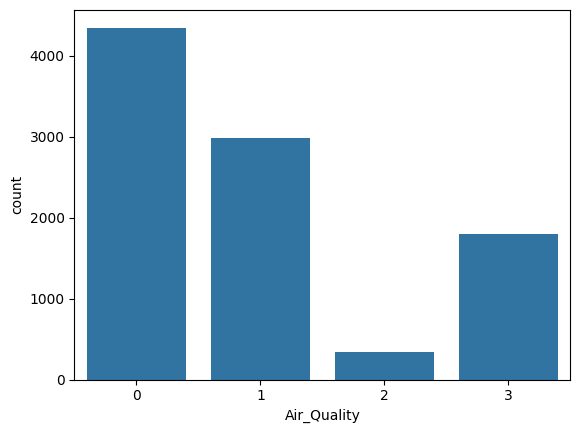

In [26]:
sns.countplot(x="Air_Quality", data=air_df)
plt.show()

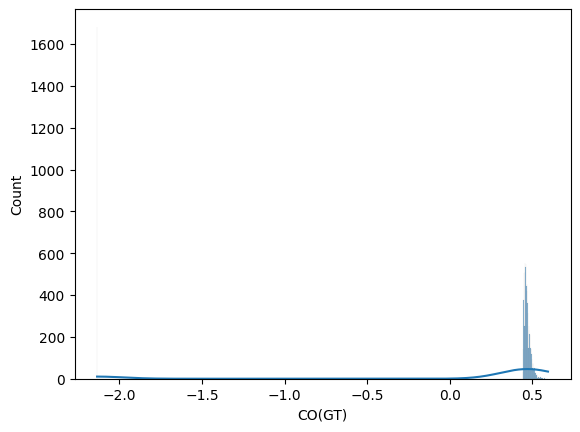

In [27]:
sns.histplot(air_df["CO(GT)"], kde=True)
plt.show()

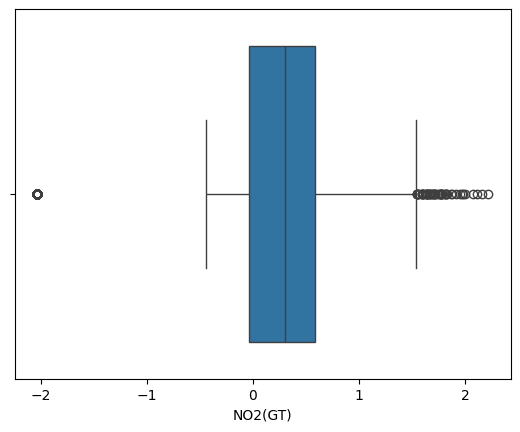

In [28]:
sns.boxplot(x=air_df["NO2(GT)"])
plt.show()

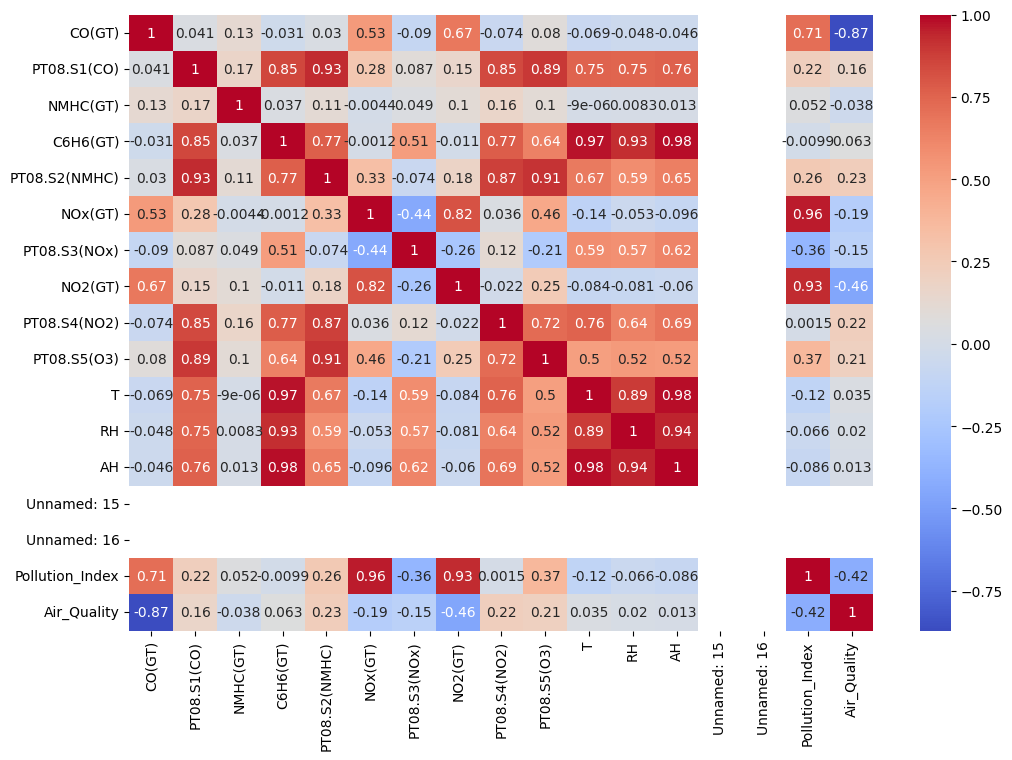

In [30]:
plt.figure(figsize=(12,8))

numeric_df = air_df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.show()

In [31]:
X = air_df.drop("Air_Quality", axis=1)

y = air_df["Air_Quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
print(air_df.dtypes)

Date                object
Time                object
CO(GT)             float64
PT08.S1(CO)        float64
NMHC(GT)           float64
C6H6(GT)           float64
PT08.S2(NMHC)      float64
NOx(GT)            float64
PT08.S3(NOx)       float64
NO2(GT)            float64
PT08.S4(NO2)       float64
PT08.S5(O3)        float64
T                  float64
RH                 float64
AH                 float64
Unnamed: 15        float64
Unnamed: 16        float64
Pollution_Index    float64
Air_Quality          int64
dtype: object


In [34]:
air_df = air_df.drop(columns=["Unnamed: 15", "Unnamed: 16"], errors="ignore")

In [38]:
# Convert Date
air_df["Date"] = pd.to_datetime(air_df["Date"], format="%d/%m/%Y")

air_df["Day"] = air_df["Date"].dt.day
air_df["Month"] = air_df["Date"].dt.month
air_df["Year"] = air_df["Date"].dt.year

# Drop original columns
air_df = air_df.drop(columns=["Date", "Time"])

In [39]:
X = air_df.drop("Air_Quality", axis=1)
y = air_df["Air_Quality"]

In [40]:
model = LogisticRegression(max_iter=500)

model.fit(X_train, y_train)

ValueError: could not convert string to float: '19/01/2005'

In [42]:
print(X_train.dtypes)



Date                object
Time                object
CO(GT)             float64
PT08.S1(CO)        float64
NMHC(GT)           float64
C6H6(GT)           float64
PT08.S2(NMHC)      float64
NOx(GT)            float64
PT08.S3(NOx)       float64
NO2(GT)            float64
PT08.S4(NO2)       float64
PT08.S5(O3)        float64
T                  float64
RH                 float64
AH                 float64
Unnamed: 15        float64
Unnamed: 16        float64
Pollution_Index    float64
dtype: object


In [43]:
print(X_train.select_dtypes(include="object").columns)

Index(['Date', 'Time'], dtype='object')


In [44]:
# Drop string columns
air_df = air_df.drop(columns=["Date", "Time", "Unnamed: 15", "Unnamed: 16"], errors="ignore")

# Create X and y AGAIN
X = air_df.drop("Air_Quality", axis=1)
y = air_df["Air_Quality"]

# Split AGAIN
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [45]:
print(X.isnull().sum())

CO(GT)             114
PT08.S1(CO)        114
NMHC(GT)           114
C6H6(GT)           114
PT08.S2(NMHC)      114
NOx(GT)            114
PT08.S3(NOx)       114
NO2(GT)            114
PT08.S4(NO2)       114
PT08.S5(O3)        114
T                  114
RH                 114
AH                 114
Pollution_Index    114
Day                114
Month              114
Year               114
dtype: int64


In [46]:
X = X.fillna(X.mean(numeric_only=True))

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train)

[[ 0.48260435 -0.10086472 -0.29302828 ...  0.35338928 -1.55261592
   1.78402138]
 [ 0.46460955 -0.39537379 -0.29302828 ...  0.92513144  0.49745988
  -0.56739904]
 [ 0.49674312  0.86160308 -0.29302828 ... -1.47618563  1.37606379
  -0.56739904]
 ...
 [ 0.49545778  1.18647392 -0.29302828 ...  0.58208614  1.08319582
  -0.56739904]
 [ 0.50059915  1.11967804  5.1233303  ... -0.10400445 -0.67401201
  -0.56739904]
 [ 0.49802846  1.16218451 -0.29302828 ... -1.0187919  -1.55261592
   1.78402138]]


In [50]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)

model.fit(X_train, y_train)

LogisticRegression(max_iter=500)

In [51]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)

model.fit(X_train, y_train)

LogisticRegression(max_iter=500)

In [54]:
prediction = model.predict(X_test)

In [55]:
print("Accuracy:", accuracy_score(y_test, prediction))
print()

print("Confusion Matrix")
print(confusion_matrix(y_test, prediction))
print()

print("Classification Report")
print(classification_report(y_test, prediction))

Accuracy: 0.9160949868073879

Confusion Matrix
[[850  52   0   0]
 [ 76 503   8   0]
 [  0  23  52   0]
 [  0   0   0 331]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       902
           1       0.87      0.86      0.86       587
           2       0.87      0.69      0.77        75
           3       1.00      1.00      1.00       331

    accuracy                           0.92      1895
   macro avg       0.91      0.87      0.89      1895
weighted avg       0.92      0.92      0.92      1895



In [ ]:
# 1. Removed empty columns because they contained no useful data.
# 2. Replaced -200 with NaN since it represents missing values.
# 3. Filled missing values using the mean to preserve the dataset.
# 4. Created Air_Quality as the target variable for classification.
# 5. Added Pollution_Index to summarize overall pollution.
# 6. Used LabelEncoder to convert class labels into numeric values.
# 7. Used pd.get_dummies() for Date and Time because they are categorical.
# 8. Applied StandardScaler to normalize numerical features.
# 9. Split the dataset into training and testing sets to evaluate model performance.
# 10. Logistic Regression predicts the air quality category (Good, Moderate, Poor).